Import libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

Load the dataset

In [2]:
# Load the dataset
file_path = 'mp_dataset_processed.xlsx'
mp_dataset_processed = pd.read_excel(file_path, engine='openpyxl').drop(['Formulation Index'], axis=1)
mp_dataset_processed

,Drug MW,Drug TPSA,Drug LogP,Polymer MW,LA/GA,Initial Drug-to-Polymer Ratio,Particle Size,Drug Loading Capacity,Drug Encapsulation Efficiency,Solubility Enhancer Concentration,Time,Release
0,639.830,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.30,0.5,0.000000,0.000000
1,639.830,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.30,0.5,1.889764,0.062622
2,639.830,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.30,0.5,7.181102,0.056751
3,639.830,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.30,0.5,13.984252,0.058708
4,639.830,116.04,5.7289,75.0,3.0,0.666667,47.723,35.41,88.30,0.5,27.968504,0.058708
...,...,...,...,...,...,...,...,...,...,...,...,...
4908,360.406,84.12,1.1031,20.0,3.0,0.112347,42.360,7.96,80.16,0.0,3.078327,0.210131
4909,360.406,84.12,1.1031,20.0,3.0,0.112347,42.360,7.96,80.16,0.0,7.068903,0.337711
4910,360.406,84.12,1.1031,20.0,3.0,0.112347,42.360,7.96,80.16,0.0,14.089168,0.613508
4911,360.406,84.12,1.1031,20.0,3.0,0.112347,42.360,7.96,80.16,0.0,21.110465,0.911820


Correlation analysis

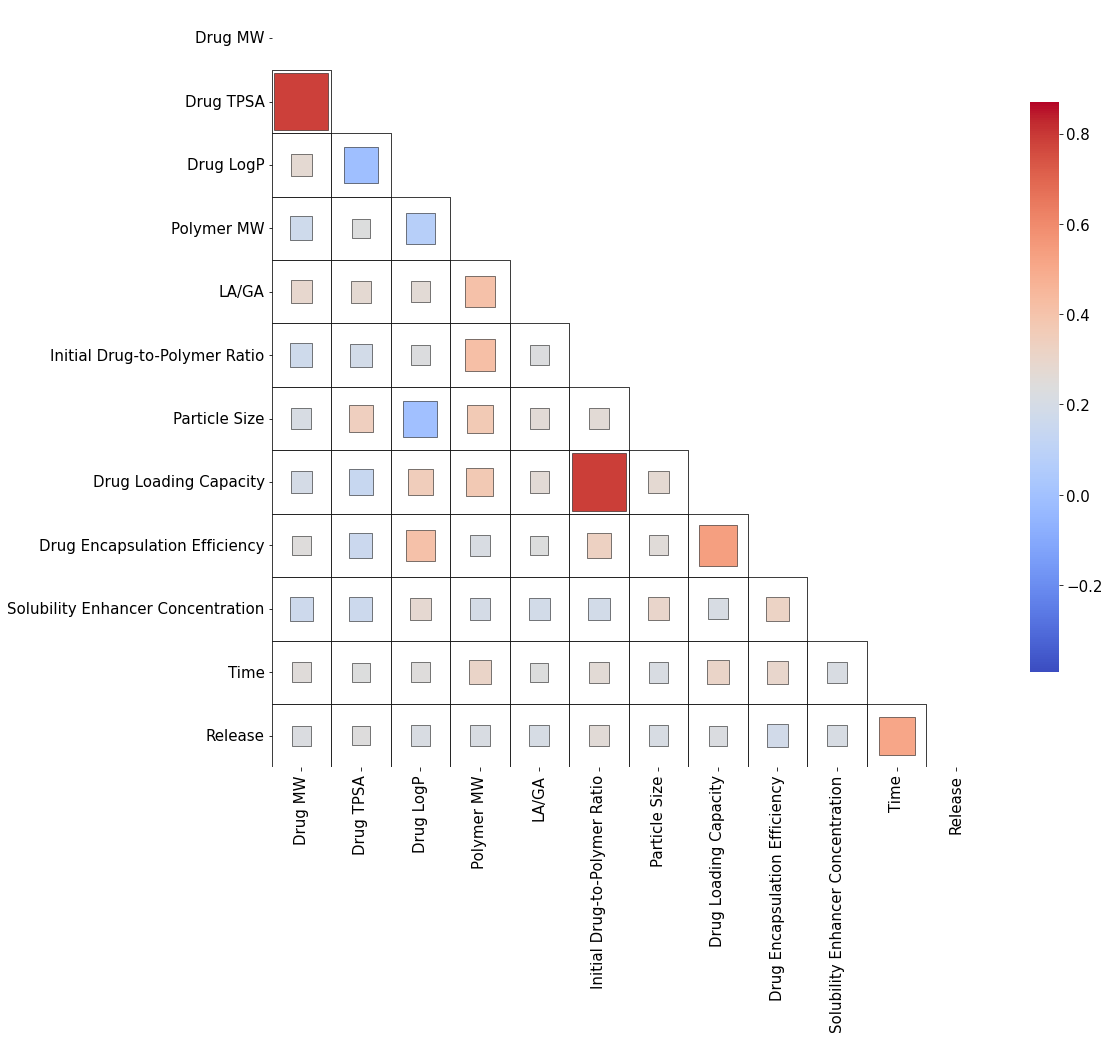

In [3]:
# Calculate the correlation matrix
corr_matrix = mp_dataset_processed.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Define the colormap and normalization
cmap = sns.diverging_palette(240, 10, as_cmap=True)
norm = plt.Normalize(-1, 1)

# Set up the matplotlib figure
plt.figure(figsize=(16, 14))

# Draw the heatmap with the mask and correct aspect ratio
heatmap = sns.heatmap(corr_matrix, mask=mask, annot=False, cmap="coolwarm", cbar_kws={"shrink": .75}, linewidths=1.)

# Set the font size of the tick labels
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=15)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=15)

# Set the colorbar tick parameters
colorbar = heatmap.collections[0].colorbar
colorbar.ax.tick_params(labelsize=15)

# Get the current axes
ax = plt.gca()
num_vars = len(corr_matrix.columns)
x_positions = np.arange(num_vars) + 0.5

# Define the area range for the rectangles
max_area = 1 
min_area = 0.3
line_width = 0.5

# Draw white rectangles in the lower triangle
for i in range(num_vars):
    for j in range(num_vars):
        if i > j:
            rect = plt.Rectangle((j, i), 1, 1, facecolor='white', edgecolor='black', linewidth=line_width)
            ax.add_patch(rect)
            rect_original = plt.Rectangle((j, i), 1, 1, facecolor='none', edgecolor='black', linewidth=line_width)
            ax.add_patch(rect_original)

# Draw resized rectangles based on correlation values
for i in range(num_vars):
    for j in range(num_vars):
        if i > j:
            corr_value = corr_matrix.iloc[i, j]
            abs_corr_value = abs(corr_value)
            area = min_area + (max_area - min_area) * abs_corr_value 
            center_x = j + 0.5
            center_y = i + 0.5
            rect_resized = plt.Rectangle((center_x - area / 2, center_y - area / 2), area, area,
                                         facecolor=plt.cm.coolwarm(norm(corr_value)),
                                         edgecolor='black', linewidth=line_width)
            ax.add_patch(rect_resized)

# Draw curved lines in the upper triangle
# off = 0.2
# offset_x = off 
# offset_y = -off 
# for i in range(num_vars):
#     for j in range(i + 1, num_vars):
#         corr_value = corr_matrix.iloc[i, j]
#         curve_line_width = (abs(corr_value) * 15) + 4  
#         color = plt.cm.coolwarm(norm(corr_value)) 
        
#         connectionstyle = f"arc3,rad={-0.6}"
#         line = FancyArrowPatch((x_positions[i] + offset_x, x_positions[i] + offset_y), 
#                                (x_positions[j] + offset_x, x_positions[j] + offset_y),
#                                connectionstyle=connectionstyle, color=color, linewidth=curve_line_width, alpha=0.6)
#         ax.add_patch(line)

# Save the figure and display
plt.savefig('correlation.png', dpi=300, bbox_inches='tight')
plt.show()


Distribution

In [4]:
blue = '#508CAF'
red = '#DC7471'

def plot_violin_plots(data, low, high, fontsize=12):
    columns_to_plot = [col for col in data.columns]
    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
    axes = axes.flatten()
    units = [' (Da)', ' (Å²)', '', ' (kDa)', '', '', ' (µm)', ' (%)', ' (%)', ' (%)', ' (Days)', '']
    for i, col in enumerate(columns_to_plot):

        plow = data[col].quantile(low)
        phigh = data[col].quantile(high)
        
        sns.violinplot(data=data, y=col, ax=axes[i], inner=None, cut=0, color=blue, linewidth=1)
        axes[i].set_title('', fontsize=fontsize)
        axes[i].set_ylabel(col + units[i], fontsize=fontsize)
        axes[i].tick_params(axis='y', labelsize=fontsize)
        axes[i].tick_params(axis='x', bottom=False, labelbottom=False)
        axes[i].text(0.95, 0.95, f'[{plow:.1f}, {phigh:.1f}]', ha='right', va='top', transform=axes[i].transAxes, fontsize=fontsize, bbox=dict(facecolor='white', alpha=0.5))
        
        pc = axes[i].collections[0]
        paths = pc.get_paths()
        vertices = np.concatenate([path.vertices for path in paths])
        y_vals = vertices[:, 1]
        x_vals = vertices[:, 0]
        mask = (y_vals >= plow) & (y_vals <= phigh)
        axes[i].fill_betweenx(y_vals, 0, x_vals, where=mask, color=red, alpha=1)
        axes[i].plot(x_vals[mask], y_vals[mask], color='black', linewidth=0.2)
        axes[i].plot(-x_vals[mask], y_vals[mask], color='black', linewidth=0.2)
                
    plt.subplots_adjust(wspace=0.4, hspace=0.2)

    fig.canvas.print_figure('distribution.png', dpi=300)

    plt.show()

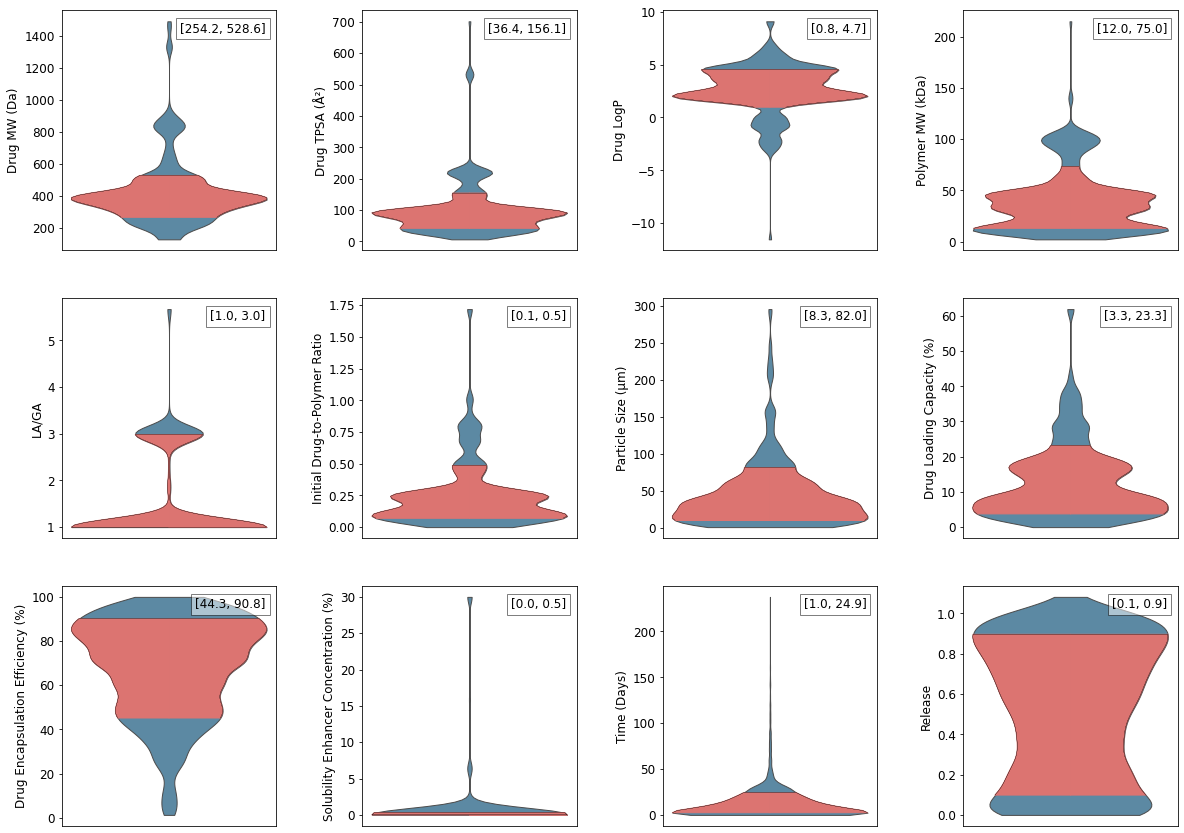

In [5]:
plot_violin_plots(mp_dataset_processed, 0.15, 0.85)